# ALS and TDP-43 depletion Comparative Transcriptomics

This notebook investigates whether transcriptomic alterations associated with amyotrophic lateral sclerosis (ALS) resemble those produced by TDP-43 depletion. The analysis compares two publicly available gene-expression datasets, GSE76220 and GSE121569, obtained through the NCBI Gene Expression Omnibus (GEO).

TDP-43 is an RNA-binding protein encoded by the TARDBP gene and plays important roles in RNA processing and regulation. Under normal conditions, TDP-43 is predominantly localized within the nucleus, although it can shuttle between the nucleus and cytoplasm. In ALS, TDP-43 pathology is commonly characterized by the loss of normal nuclear TDP-43 and its abnormal accumulation in the cytoplasm, disrupting its normal cellular functions. Experimental depletion of TDP-43 therefore provides one approach for investigating how loss of normal TDP-43 function may alter gene expression and whether aspects of those alterations resemble transcriptomic changes observed in ALS.

The notebook uses visualisation, statistical testing for each gene, multiple-testing correction, gene-identifier matching, comparison of gene-expression changes between the two datasets, overlap and directional-agreement testing, genes of interest, and functional enrichment. These different steps are used to investigate whether the changes seen in ALS and after TDP-43 depletion show any shared or similar patterns.

This analysis is exploratory and is looking for a possible relationship or agreement between the two transcriptomic signatures, rather than trying to prove that TDP-43 depletion causes ALS. If similar gene-expression changes or biological processes are found in both datasets, this would suggest an area of shared biology that could be investigated further, but it would not by itself prove a causal relationship.

In [ ]:
# Install the packages needed for this notebook.
# These cover the data handling, plots, statistics and gene-ID matching used later.

!pip install pandas numpy matplotlib seaborn scipy statsmodels scikit-learn mygene

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.1/52.1 kB 2.8 MB/s eta 0:00:00


## 1. Notebook setup

The libraries below provide the main tools required for the analysis. Of particular importance is MyGene, which will later be used to map and harmonise gene identifiers so that the same genes can be correctly matched between the two datasets.

In [ ]:
# Load the libraries used throughout the analysis.
# MyGene is especially important later because it helps match gene identifiers between the two datasets.

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import (
    ttest_ind,
    spearmanr,
    hypergeom,
)

from statsmodels.stats.multitest import multipletests

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import mygene

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 150)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Introducing the datasets used

GSE76220: What transcriptional changes are present in sporadic ALS motor neurons?

## GSE76220 — ALS Spinal Motor Neuron Transcriptomic Dataset

**GSE76220**, contributed by **Batra R., Hutt K., Yeo E., and Ravits J.**, contains transcriptome-wide gene-expression measurements from adult spinal motor neurons of **13 sporadic ALS patients and 9 controls**.

Lumbar spinal motor neurons were isolated using **Laser Capture Microdissection (LCM)**, a laser-based technique used to isolate specific cells or regions of interest from heterogeneous tissue. This allowed the study to focus more specifically on motor-neuron gene expression. Total RNA was then extracted, RNA-seq libraries were prepared and sequenced using the **Illumina GA II platform**.

**Dataset:** [GSE76220](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE76220)  
**LCM background:** https://pmc.ncbi.nlm.nih.gov/articles/PMC13001730/

In this project, GSE76220 provides the **sporadic ALS disease signature**, allowing comparison of gene expression between ALS and control spinal motor neurons. A key limitation is the relatively small cohort (**13 ALS vs 9 controls**), which limits statistical power. This is important when comparing the ALS signature with TDP-43 depletion: weak or non-significant overlap cannot by itself be taken as evidence of no biological relationship, as sample size, biological heterogeneity, effect size, multiple-testing correction and differences between the experimental systems can all affect the detectable signal.

## GSE121569 — TDP-43 Depletion in Human Motor Neurons

GSE121569: What transcriptional changes occur when TDP-43 function is depleted?

**GSE121569**, contributed by **Klim JR et al.**, examines changes in gene expression following **TDP-43 depletion in human motor neurons**.

**Dataset:** [GSE121569](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE121569)

TDP-43 dysfunction is strongly associated with ALS, with TDP-43 mislocalisation observed in many patients. The study investigated which RNAs are affected when normal TDP-43 function is reduced. A major finding was the reduction of **STMN2**, caused by abnormal RNA processing and the emergence of a cryptic exon following TDP-43 depletion. (https://pmc.ncbi.nlm.nih.gov/articles/PMC10018954/)  STMN2 is important for **axonal growth and repair**, providing a possible mechanism through which TDP-43 dysfunction may contribute to neuronal damage in ALS. (https://www.genecards.org/card/STMN2), (https://www.biorxiv.org/content/10.64898/2026.01.25.701321v1)

In this project, **GSE121569 provides the TDP-43 depletion signature**, while **GSE76220 provides the sporadic ALS signature**. The analysis compares these datasets to determine whether they show **shared differentially expressed genes, directional agreement and enriched biological pathways**, while recognising that any observed association does not establish causation.

## Central Research Question

The main question behind this project is:

Do the gene-expression changes associated with sporadic ALS spinal motor neurons show measurable similarities with the gene-expression changes caused by TDP-43 depletion in human motor neurons?

GSE76220 examines gene-expression differences between sporadic ALS spinal motor neurons and controls, showing which genes may be affected in ALS. whilst GSE121569 examines gene-expression changes following TDP-43 depletion in human motor neurons, showing which genes may be affected when normal TDP-43 function is reduced.

In [ ]:
# Store the GitHub links for the files used in the analysis.
# The data are only loaded later when pd.read_csv() is called.

gse76220_expr_url = "https://raw.githubusercontent.com/VighneshGaya/ALS-transcriptomics-analysis/main/data/GSE76220/GSE76220_ALS_LCM_MPR_gene_expression.txt.gz"

gse76220_rpkm_url = "https://raw.githubusercontent.com/VighneshGaya/ALS-transcriptomics-analysis/main/data/GSE76220/GSE76220_ALS_LCM_RPKM.txt.gz"

gse121569_counts_url = "https://raw.githubusercontent.com/VighneshGaya/ALS-transcriptomics-analysis/main/data/GSE121569/GSE121569_raw_counts.csv.gz"

print(gse76220_expr_url)
print(gse76220_rpkm_url)
print(gse121569_counts_url)

https://raw.githubusercontent.com/VighneshGaya/ALS-transcriptomics-analysis/main/data/GSE76220/GSE76220_ALS_LCM_MPR_gene_expression.txt.gz
https://raw.githubusercontent.com/VighneshGaya/ALS-transcriptomics-analysis/main/data/GSE76220/GSE76220_ALS_LCM_RPKM.txt.gz
https://raw.githubusercontent.com/VighneshGaya/ALS-transcriptomics-analysis/main/data/GSE121569/GSE121569_raw_counts.csv.gz


### 2. Statistical and preprocessing functions

The functions below are applied to both datasets so that the same main statistical steps are followed throughout the analysis.

Mean and variance are first calculated, followed by Principal Component Analysis. Since thousands of genes are being analysed, there are too many dimensions to visualise directly. PCA simplifies this by reducing the data into two main components, **PC1 and PC2**. PC1 captures the largest amount of variation between the samples and PC2 captures the next largest amount independently of PC1. Plotting these together helps show whether the experimental and control samples separate, cluster together or show a lot of variation between samples.

Welch's t-test is then used to compare gene expression between the experimental and control groups. It is useful here because it does not assume that the two groups have equal variance. The starting point, or null hypothesis, assumes that there is no difference in mean expression between the groups. A small p-value gives stronger evidence against this assumption and suggests that the observed difference is less likely to be due to random sampling variation.

However, thousands of genes are being tested, meaning that some small p-values can appear simply by chance. The Benjamini-Hochberg false discovery rate correction at 5% is therefore used to control false discoveries and provide a more reliable set of significant genes for the later comparison between ALS and TDP-43 depletion.

In [ ]:
# Adjust the raw p-values using the Benjamini-Hochberg FDR method.
# This is needed because thousands of genes are tested and some small p-values can appear by chance.

def calculate_fdr(pvalues):
    """
    Apply Benjamini-Hochberg multiple-testing correction.
    """

    # Put the p-values into one numeric Series so they are easier to check and correct.
    pvalues = pd.Series(
        pvalues,
        dtype=float
    )

    adjusted = pd.Series(
        np.nan,
        index=pvalues.index,
        dtype=float
    )

    # Only finite, non-missing p-values should be sent into the FDR correction.
    valid = (
        pvalues.notna()
        & np.isfinite(pvalues)
    )

    if valid.any():

        # multipletests returns the adjusted p-values in position [1].
        adjusted.loc[valid] = multipletests(
            pvalues.loc[valid],
            method="fdr_bh"
        )[1]

    return adjusted

### 3 Expression-matrix quality control

Expression values must be numeric and finite. Genes containing missing values are removed by the current workflow, as are genes with zero variance because they cannot contribute to separation or gene-wise variance-based testing.

In [ ]:
# Clean the expression matrix before PCA or statistical testing.
# Values that cannot be used, and genes with no variation, are removed here.

def clean_expression_matrix(expression):
    """
    Clean a genes-by-samples expression matrix.

    Removes:
    - non-numeric values
    - infinite values
    - genes containing missing values
    - genes with zero variance
    """

    expression = expression.copy()

    # Anything that cannot be read as a number becomes NaN so it can be removed safely.
    expression = expression.apply(
        pd.to_numeric,
        errors="coerce"
    )

    expression = expression.replace(
        [np.inf, -np.inf],
        np.nan
    )

    expression = expression.dropna(
        axis=0,
        how="any"
    )

    # Genes with no variation across samples add no information for PCA or group comparison.
    gene_variance = expression.var(
        axis=1,
        ddof=1
    )

    expression = expression.loc[
        gene_variance > 0
    ]

    return expression

In [ ]:
# If the same gene identifier appears more than once, combine those rows by taking their average.
# This leaves one expression profile for each gene identifier.

def collapse_duplicate_genes(expression):
    """
    Average rows with duplicated gene identifiers.
    """

    expression = expression.copy()

    expression.index = (
        expression.index
        .astype(str)
        .str.strip()
    )

    expression = expression.groupby(
        expression.index,
        sort=False
    ).mean()

    return expression

In [ ]:
# Run PCA using the 5,000 most variable genes (or fewer if the dataset has less).
# The matrix is turned around so PCA compares samples rather than genes.

def run_pca(
    expression,
    metadata,
    group_column,
    number_variable_genes=5000
):
    """
    Run PCA using the most variable genes.

    Input expression matrix:
    rows = genes
    columns = samples
    """

    # Rank genes by how much they vary across the samples.
    gene_variance = expression.var(
        axis=1,
        ddof=1
    ).sort_values(
        ascending=False
    )

    selected_genes = gene_variance.head(
        min(
            number_variable_genes,
            len(gene_variance)
        )
    ).index

    # Keep only the most variable genes, then transpose so rows become samples.
    pca_input = expression.loc[
        selected_genes
    ].T

    if not np.isfinite(
        pca_input.to_numpy(dtype=float)
    ).all():

        raise ValueError(
            "PCA input contains NaN or infinite values."
        )

    # Scale the selected genes so very large numerical ranges do not dominate PCA.
    scaled_input = StandardScaler().fit_transform(
        pca_input
    )

    # Two components are enough for the 2D PCA plots used in this notebook.
    pca_model = PCA(
        n_components=2
    )

    components = pca_model.fit_transform(
        scaled_input
    )

    pca_results = pd.DataFrame({
        "Sample": pca_input.index,
        "PC1": components[:, 0],
        "PC2": components[:, 1]
    })

    pca_results = pca_results.merge(
        metadata,
        on="Sample",
        how="left"
    )

    return (
        pca_results,
        pca_model,
        selected_genes
    )

In [ ]:
# Plot PC1 against PC2 so the main sample-to-sample variation can be seen.
# The percentage on each axis shows how much of the total variation that component explains.

def plot_pca(
    pca_results,
    pca_model,
    group_column,
    title
):
    """
    Plot PC1 against PC2.
    """

    plt.figure(
        figsize=(8, 6)
    )

    sns.scatterplot(
        data=pca_results,
        x="PC1",
        y="PC2",
        hue=group_column,
        s=100
    )

    for _, row in pca_results.iterrows():

        plt.text(
            row["PC1"],
            row["PC2"],
            row["Sample"],
            fontsize=7
        )

    pc1_variance = (
        pca_model.explained_variance_ratio_[0]
        * 100
    )

    pc2_variance = (
        pca_model.explained_variance_ratio_[1]
        * 100
    )

    plt.xlabel(
        f"PC1 ({pc1_variance:.1f}% variance)"
    )

    plt.ylabel(
        f"PC2 ({pc2_variance:.1f}% variance)"
    )

    plt.title(title)

    plt.tight_layout()
    plt.show()

In [ ]:
# Compare the case and control groups for each gene using Welch's t-test.
# The effect is calculated as mean(case) - mean(control), then the p-values are corrected using FDR.

def run_welch_differential_expression(
    expression,
    case_samples,
    control_samples,
    effect_column
):
    """
    Run gene-wise Welch t-tests.

    Effect:
        mean(case) - mean(control)
    """

    case_expression = expression[
        case_samples
    ]

    control_expression = expression[
        control_samples
    ]

    # Calculate the average expression of each gene in the case group.
    case_mean = case_expression.mean(
        axis=1
    )

    control_mean = control_expression.mean(
        axis=1
    )

    # Positive effect = higher in case; negative effect = lower in case.
    effect = case_mean - control_mean

    # equal_var=False makes this Welch's t-test rather than the equal-variance t-test.
    t_statistics, pvalues = ttest_ind(
        case_expression.to_numpy(dtype=float),
        control_expression.to_numpy(dtype=float),
        axis=1,
        equal_var=False,
        nan_policy="omit"
    )

    results = pd.DataFrame({
        "Gene": expression.index.astype(str),
        "mean_case": case_mean.to_numpy(),
        "mean_control": control_mean.to_numpy(),
        effect_column: effect.to_numpy(),
        "t_statistic": t_statistics,
        "pvalue": pvalues
    })

    # Correct the raw p-values because the test is repeated across thousands of genes.
    results["FDR"] = calculate_fdr(
        results["pvalue"]
    )

    results["negative_log10_FDR"] = -np.log10(
        results["FDR"].clip(
            lower=1e-300
        )
    )

    results = results.sort_values(
        ["FDR", "pvalue"],
        na_position="last"
    ).reset_index(drop=True)

    return results

In [ ]:
# Plot each gene's expression effect against its actual FDR value.
# Genes below the FDR 0.05 line and beyond the chosen effect cut-off would meet both thresholds.

def plot_volcano(
    results,
    effect_column,
    title,
    effect_threshold=0.5,
    fdr_threshold=0.05
):
    # Make a copy so the original results are not changed
    plot_data = results.copy()

    # A gene is significant if its FDR is below 0.05
    # and its expression change is large enough
    # A point is highlighted only if it passes both the FDR and effect-size cut-offs.
    plot_data["Significant"] = (
        (plot_data["FDR"] <= fdr_threshold) &
        (plot_data[effect_column].abs() >= effect_threshold)
    )

    # Plot the expression effect against the actual FDR value
    plt.figure(figsize=(9, 6))

    plt.scatter(
        plot_data[effect_column],
        plot_data["FDR"],
        alpha=0.6
    )

    # The horizontal line directly represents FDR = 0.05
    # The horizontal dashed line is the actual FDR = 0.05 threshold.
    plt.axhline(
        y=fdr_threshold,
        linestyle="--"
    )

    # These lines show the chosen expression-effect cut-offs
    plt.axvline(
        x=-effect_threshold,
        linestyle="--"
    )

    plt.axvline(
        x=effect_threshold,
        linestyle="--"
    )

    plt.xlabel(effect_column)
    plt.ylabel("FDR")
    plt.title(title)

    plt.tight_layout()
    plt.show()

## 4 Load and inspect GSE76220

The ALS dataset is loaded first and its dimensions, column names, and initial rows are inspected before any biological inference is attempted.


In [ ]:
# Load the GSE76220 RPKM table from GitHub.
# Display its size, first rows and columns first so the structure can be checked before analysis.

gse76220_raw = pd.read_csv(
    gse76220_rpkm_url,
    sep="\t",
    compression="gzip"
)

print(
    "Raw GSE76220 shape:",
    gse76220_raw.shape
)

display(
    gse76220_raw.head()
)

print(
    gse76220_raw.columns.tolist()
)

Raw GSE76220 shape: (25856, 25)


,Gene_symbol,60a,62a,63a,84a,89a,21a,34a,79a,82a,16a,27a,48a,10c,65c,78c,39c,67c,76c,42c,44c,88c,NCBI_mRNA,NCBI_Protein,Gene_Name
0,BC032353,-3.155958,-2.968040,-3.037292,-2.178731,-2.216863,-3.566296,-2.387773,-3.489413,-2.712084,-2.958967,-2.773114,-1.819738,-2.392677,-3.283393,-3.007300,-3.350180,-3.005531,-3.227961,-2.491280,-2.665687,-2.305262,NaN,NaN,"Homo sapiens cDNA FLJ36366 fis, clone THYMU200..."
1,DQ599874,-2.205057,-2.017138,-2.086390,-1.227829,-1.265961,-2.615394,-1.436871,-2.538511,-1.761182,-2.008065,-1.822212,-0.868836,-1.441775,-2.332491,-2.056399,-2.399278,-2.054629,-2.277059,-1.540378,-1.714785,-1.354361,NaN,NaN,DQ599874
2,hCG_1770745,-3.433302,-3.245384,-3.314636,-2.456075,-2.494207,-3.843640,-2.665117,-3.766757,-2.989428,-3.236311,-3.050458,-2.097082,-2.670021,-3.560737,-3.284644,-3.627524,-3.282875,-3.505305,-2.768624,-2.943031,-2.582606,NaN,NaN,"cDNA FLJ10346 fis, clone NT2RM2001004 (HCG1770..."
3,GNG5,-1.510434,-0.852512,-3.001206,-2.142645,-1.082164,-3.530210,-2.351686,-3.453327,-2.675997,-0.620296,-2.043880,-1.783652,-2.356591,-2.554159,-2.971214,-2.620946,-2.969445,-3.191875,-1.356581,-2.629600,-2.269176,NM_005274,NP_005265,"guanine nucleotide binding protein (G protein),"
4,AK057887,0.846334,0.766773,0.117702,-0.458821,0.838048,-0.105920,0.396848,-0.638101,-0.250236,1.194556,0.771345,0.162536,0.831310,-0.339708,-0.699604,-0.406495,-0.643768,-2.018877,1.617393,0.812081,0.107795,NaN,NaN,"Homo sapiens cDNA FLJ31635 fis, clone NT2RI200..."


['Gene_symbol', '60a', '62a', '63a', '84a', '89a', '21a', '34a', '79a', '82a', '16a', '27a', '48a', '10c', '65c', '78c', '39c', '67c', '76c', '42c', '44c', '88c', 'NCBI_mRNA', 'NCBI_Protein', 'Gene_Name']


In [ ]:
# Find the columns that match the sample naming pattern in GSE76220.
# In this dataset the sample names end in 'a' for ALS or 'c' for Control.

import re

gse76220_sample_columns = [
    column
    for column in gse76220_raw.columns
    if re.fullmatch(r"\d+[ac]", str(column).lower())
]

print("Detected sample columns:", len(gse76220_sample_columns))
print(gse76220_sample_columns)

Detected sample columns: 21
['60a', '62a', '63a', '84a', '89a', '21a', '34a', '79a', '82a', '16a', '27a', '48a', '10c', '65c', '78c', '39c', '67c', '76c', '42c', '44c', '88c']


In [ ]:
# Build the gene-by-sample matrix that will be used for the ALS analysis.
# Keep the sample columns, make them numeric, combine duplicate gene symbols and clean unusable rows.

if "Gene_symbol" not in gse76220_raw.columns:
    raise KeyError("Gene_symbol column was not found.")

# Keep only the actual sample columns
gse76220_expression = gse76220_raw[
    ["Gene_symbol"] + gse76220_sample_columns
].copy()

# Make sample values numeric
for column in gse76220_sample_columns:
    gse76220_expression[column] = pd.to_numeric(
        gse76220_expression[column],
        errors="coerce"
    )

# Remove missing gene names
gse76220_expression = gse76220_expression.dropna(
    subset=["Gene_symbol"]
)

# Average duplicated gene symbols
gse76220_expression = (
    gse76220_expression
    .groupby("Gene_symbol")[gse76220_sample_columns]
    .mean()
)

# Remove rows with missing or constant values
gse76220_expression = clean_expression_matrix(
    gse76220_expression
)

print("Clean GSE76220 matrix:", gse76220_expression.shape)
display(gse76220_expression.head())

Clean GSE76220 matrix: (24653, 21)


,60a,62a,63a,84a,89a,21a,34a,79a,82a,16a,27a,48a,10c,65c,78c,39c,67c,76c,42c,44c,88c
Gene_symbol,,,,,,,,,,,,,,,,,,,,,
1-Mar,1.630521,1.644086,0.798995,0.487485,0.960179,0.945747,1.770098,0.829726,1.648728,0.768121,1.359439,1.539625,1.372151,1.707387,1.245881,1.293199,1.074378,1.192274,0.973444,1.135509,1.208251
1-Oct,-0.366046,0.501414,-2.066538,-2.306590,-1.939256,-4.387302,-1.011554,-2.518660,-1.335865,-0.889601,-0.226824,-0.848984,-1.016458,-2.718104,-3.828306,-2.225276,-1.053948,-1.215753,-0.539697,-2.100398,-3.126268
1-Sep,3.747118,3.584988,2.619563,1.944571,4.813235,2.496024,3.433259,2.254799,2.832935,3.266356,4.169160,3.275944,2.333258,1.885877,2.055107,2.705200,2.513634,1.432733,3.364358,3.377080,2.150382
10-Mar,-1.513896,-0.499299,-0.943245,0.002327,-1.422099,0.207393,-2.691621,0.056886,-0.618036,-1.183374,-1.467524,0.709627,-2.696525,-0.591509,-0.366710,-1.574586,0.057916,-0.966860,-2.101981,-0.772310,-0.306526
10-Sep,3.009551,2.984034,2.870331,2.764757,3.439445,2.576519,2.508249,2.572360,2.999487,3.107126,3.342385,2.950658,2.899508,2.493580,2.492962,2.624582,2.485198,2.480533,2.728234,2.879109,2.601122


## 5. GSE76220: ALS motor-neuron dataset

The GSE76220 expression matrix contains some negative values and has already been processed to some capacity. An additional log2(x + 1) transformation is therefore not applied, as values below −1 would produce NaN values. Instead, missing/non-finite values and zero-variance genes are cleaned before analysis.

Samples are then grouped into ALS and Control, followed by PCA. Welch's t-test is then applied to each gene to compare expression between the two groups, and the resulting p-values are corrected using the Benjamini–Hochberg FDR procedure.

##6 Identify ALS and Control Samples

The sample names are used to separate the samples into ALS and Control groups. The number in each group is then checked to make sure the samples have been identified correctly before PCA and the statistical analysis.


In [ ]:
# Use the sample-name endings to label each GSE76220 sample as ALS or Control.
# This creates the group labels needed for PCA and the later statistical comparison.

gse76220_metadata = pd.DataFrame({
    "Sample": gse76220_sample_columns
})

gse76220_metadata["Condition"] = np.where(
    gse76220_metadata["Sample"]
    .str.lower()
    .str.endswith("a"),
    "ALS",
    "Control"
)

display(
    gse76220_metadata
)

print(
    gse76220_metadata[
        "Condition"
    ].value_counts()
)

,Sample,Condition
0,60a,ALS
1,62a,ALS
2,63a,ALS
3,84a,ALS
4,89a,ALS
5,21a,ALS
6,34a,ALS
7,79a,ALS
8,82a,ALS
9,16a,ALS


Condition
ALS        12
Control     9
Name: count, dtype: int64


In [ ]:
# Count the ALS and Control samples to check that the grouping worked as expected.

als_sample_count = (
    gse76220_metadata[
        "Condition"
    ] == "ALS"
).sum()

control_sample_count = (
    gse76220_metadata[
        "Condition"
    ] == "Control"
).sum()

print(
    "ALS samples:",
    als_sample_count
)

print(
    "Control samples:",
    control_sample_count
)

if als_sample_count < 2 or control_sample_count < 2:

    raise ValueError(
        "Both groups require at least two samples."
    )

ALS samples: 12
Control samples: 9


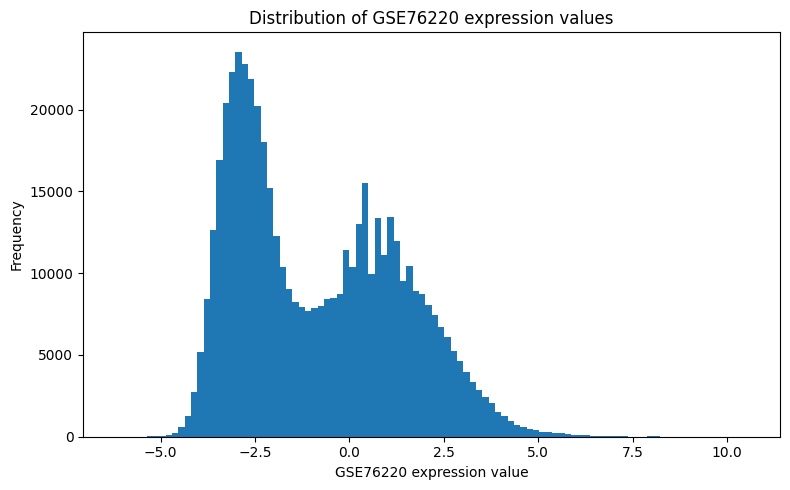

In [ ]:
# Plot all GSE76220 expression values together to inspect their overall distribution.
# This also shows why another log2(x + 1) transformation is not appropriate for these already processed values.

plt.figure(
    figsize=(8, 5)
)

plt.hist(
    gse76220_expression
    .to_numpy()
    .ravel(),
    bins=100
)

plt.xlabel(
    "GSE76220 expression value"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Distribution of GSE76220 expression values"
)

plt.tight_layout()
plt.show()

The graph above shows the expression values across the ALS and Control samples. Many of the supplied values are negative because the dataset has already been processed or transformed. Since many values are below −1, applying another log2(x + 1) transformation would produce invalid values, so the supplied values are kept as they are. log2 transformations are commonly used with gene-expression data to reduce large ranges of expression values and make the data easier to explore (https://www.biostars.org/p/242573/)


In [ ]:
# Summarise each GSE76220 sample using simple statistics.
# This gives a quick check for samples whose overall distribution looks very different from the others.

gse76220_sample_summary = pd.DataFrame({
    "Sample": gse76220_expression.columns,
    "Mean": gse76220_expression.mean(
        axis=0
    ).values,
    "Median": gse76220_expression.median(
        axis=0
    ).values,
    "Standard_deviation": gse76220_expression.std(
        axis=0
    ).values
})

gse76220_sample_summary = (
    gse76220_sample_summary.merge(
        gse76220_metadata,
        on="Sample",
        how="left"
    )
)

display(
    gse76220_sample_summary
)

,Sample,Mean,Median,Standard_deviation,Condition
0,60a,-0.765358,-0.804465,2.310713,ALS
1,62a,-0.669223,-0.697486,2.268958,ALS
2,63a,-1.046282,-1.481088,2.194268,ALS
3,84a,-0.703500,-1.436287,1.881652,ALS
4,89a,-0.311328,-0.570354,2.007675,ALS
5,21a,-1.303823,-1.654103,2.389960,ALS
6,34a,-0.545940,-0.980156,2.045437,ALS
7,79a,-1.241400,-1.633846,2.381901,ALS
8,82a,-0.851363,-1.382385,2.117752,ALS
9,16a,-0.744537,-0.825682,2.200434,ALS


##7 PCA of GSE76220

The 5,000 most variable genes are used for PCA to examine how the ALS and Control samples group or separate based on their overall gene-expression patterns.

,Sample,PC1,PC2,Condition
0,60a,38.850943,-26.393239,ALS
1,62a,44.702174,-42.083462,ALS
2,63a,-19.508534,-3.909633,ALS
3,84a,-13.240873,18.706129,ALS
4,89a,75.049709,-1.218654,ALS
5,21a,-50.385964,-14.365090,ALS
6,34a,39.850268,16.189549,ALS
7,79a,-46.732319,-11.135279,ALS
8,82a,-0.861625,-3.465196,ALS
9,16a,32.946801,-20.289004,ALS


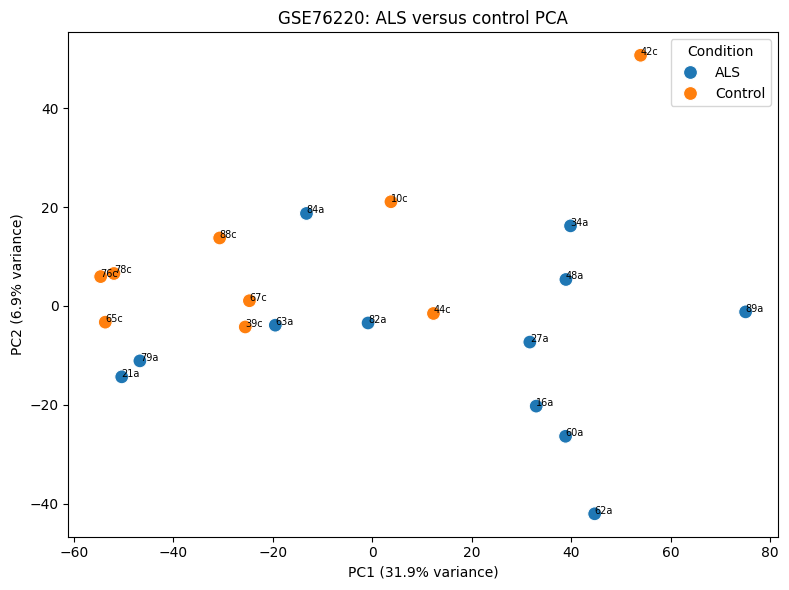

In [ ]:
# Run PCA on the 5,000 most variable genes in the ALS dataset.
# The result gives a 2D view of how the ALS and Control samples group or separate.

(
    gse76220_pca_results,
    gse76220_pca_model,
    gse76220_pca_genes
) = run_pca(
    expression=gse76220_expression,
    metadata=gse76220_metadata,
    group_column="Condition",
    number_variable_genes=5000
)

display(
    gse76220_pca_results
)

plot_pca(
    pca_results=gse76220_pca_results,
    pca_model=gse76220_pca_model,
    group_column="Condition",
    title="GSE76220: ALS versus control PCA"
)

The PCA shows some separation between the ALS and Control samples, mainly along PC1, which explains 31.9% of the variation, while PC2 explains a further 6.9%. Many Control samples appear towards the left and several ALS samples towards the right, although there is still considerable overlap and variation within both groups, particularly Control sample 42c. PC1 and PC2 therefore provide a useful 2D view for this initial comparison without adding the complexity of a third component.



In [ ]:
# Separate the sample names into ALS and Control lists.
# These two lists are passed into the Welch's t-test function below.

als_samples = gse76220_metadata.loc[
    gse76220_metadata["Condition"] == "ALS",
    "Sample"
].tolist()

als_control_samples = gse76220_metadata.loc[
    gse76220_metadata["Condition"] == "Control",
    "Sample"
].tolist()

print(
    "ALS samples:",
    als_samples
)

print(
    "Control samples:",
    als_control_samples
)

ALS samples: ['60a', '62a', '63a', '84a', '89a', '21a', '34a', '79a', '82a', '16a', '27a', '48a']
Control samples: ['10c', '65c', '78c', '39c', '67c', '76c', '42c', '44c', '88c']


##8 Gene-expression differences in GSE76220

For each gene, the average expression in ALS is compared with the average expression in Control using Welch's t-test. The difference is calculated as mean(ALS) − mean(Control), showing the direction of the change. The resulting p-values are then corrected using Benjamini–Hochberg FDR because thousands of genes are being tested at the same time, increasing the chance of finding small p-values simply by chance. The FDR correction helps control these false discoveries and provides a more reliable set of significant results.


In [ ]:
# Compare ALS against Control for every gene.
# A positive ALS_effect means higher average expression in ALS; a negative value means lower average expression.

gse76220_de = run_welch_differential_expression(
    expression=gse76220_expression,
    case_samples=als_samples,
    control_samples=als_control_samples,
    effect_column="ALS_effect"
)

display(
    gse76220_de.head(20)
)

print(
    "FDR-significant genes:",
    (
        gse76220_de["FDR"] < 0.05
    ).sum()
)
print("Minimum p-value:", gse76220_de["pvalue"].min())
print("Minimum FDR:", gse76220_de["FDR"].min())

,Gene,mean_case,mean_control,ALS_effect,t_statistic,pvalue,FDR,negative_log10_FDR
0,KCNA1,3.603041,4.089849,-0.486808,-5.659459,0.000030,0.239433,0.620816
1,KLHL18,0.846624,-0.682934,1.529557,5.786853,0.000036,0.239433,0.620816
2,CUX2,-0.509880,0.921425,-1.431305,-5.343645,0.000038,0.239433,0.620816
3,GJA5,-0.524996,-2.976832,2.451837,5.394947,0.000042,0.239433,0.620816
4,MIR16,3.169925,2.804355,0.365570,5.433953,0.000049,0.239433,0.620816
5,DOPEY2,-0.267194,0.382242,-0.649436,-5.237812,0.000081,0.243585,0.613350
6,EPB41,2.583724,2.986121,-0.402397,-5.010623,0.000084,0.243585,0.613350
7,PRUNE2,4.683944,5.683989,-1.000045,-5.503405,0.000088,0.243585,0.613350
8,CD22,-0.163616,-2.374715,2.211098,4.907976,0.000100,0.243585,0.613350
9,BC005981,1.430237,0.392239,1.037999,5.110719,0.000105,0.243585,0.613350


FDR-significant genes: 0
Minimum p-value: 3.0039982321425413e-05
Minimum FDR: 0.23943289740401583


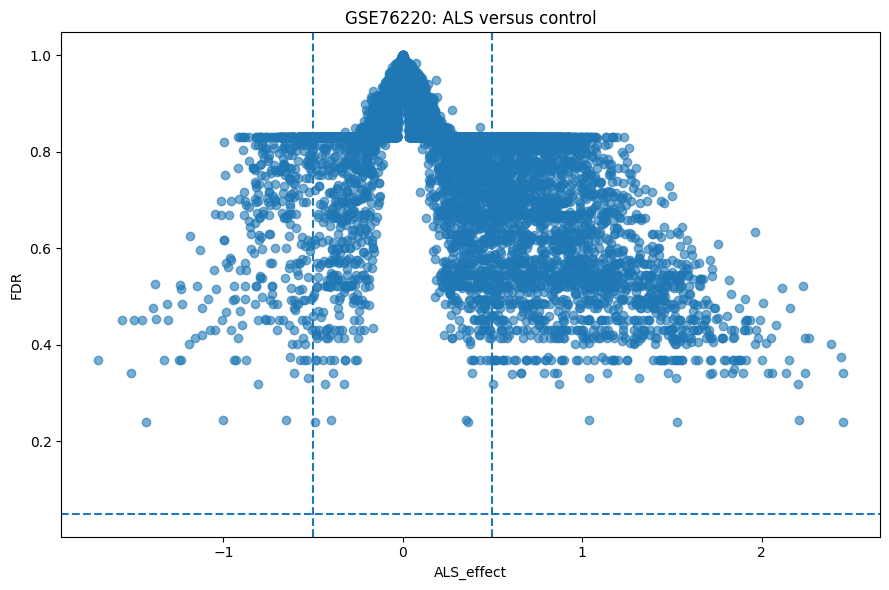

In [ ]:
# Plot the ALS effect for each gene against its FDR value.
# The horizontal line at 0.05 makes it easy to see whether any genes survive FDR correction.

plot_volcano(
    results=gse76220_de,
    effect_column="ALS_effect",
    title="GSE76220: ALS versus control",
    effect_threshold=0.5,
    fdr_threshold=0.05
)

The graph above uses the FDR values on the y-axis. Smaller FDR values provide stronger statistical evidence, so genes need to fall below the dashed FDR threshold of 0.05 to be considered statistically significant. In this case, none of the genes fall below the 0.05 threshold, meaning that no genes remain statistically significant after the Benjamini–Hochberg correction.

In [ ]:
# Load the second GSE76220 table (MPR).
# This table contains extra gene identifiers and annotation that can help with gene matching later.

gse76220_mpr = pd.read_csv(
    gse76220_expr_url,
    sep="\t",
    compression="gzip"
)

print(
    "GSE76220 MPR table:",
    gse76220_mpr.shape
)

display(
    gse76220_mpr.head()
)

GSE76220 MPR table: (14635, 12)


,ENS ID,Ratio MPR,Zscore MPR,Annotation,gene_ID,gene_symbol,Refseq,Protein_ID,gene name,Ratio MPR.1,Unnamed: 10,Unnamed: 11
0,6263,1.000000,1.000000,6263,AX748157,AX748157,NaN,NaN,"Homo sapiens cDNA FLJ36163 fis, clone TESTI202...",1.000000,Downregulated by MPR,NaN
1,24489,0.999742,0.999397,24489,CR598614,CR598614,NaN,NaN,full-length cDNA clone CS0DF037YH05 of Fetal b...,0.999742,Upregulated by MPR,NaN
2,21371,0.999668,0.997844,21371,BC021582,SCML4,NM_198081,NP_932347,sex comb on midleg-like 4,0.999668,NaN,NaN
3,20676,0.999630,0.999815,20676,CCDS4660,OR2H1,NM_030883,NP_112145,"olfactory receptor, family 2, subfamily H,",0.999630,NaN,NaN
4,21569,0.999483,0.998277,21569,AK123801,AK123801,NaN,NaN,"Homo sapiens cDNA FLJ41807 fis, clone NOVAR200...",0.999483,NaN,NaN


## 9. GSE121569: TDP-43 depletion dataset

The second dataset looks at what happens to gene expression when TDP-43 is reduced in human motor neurons. The samples are divided into two groups:

- siTDP43 – cells treated with small interfering RNA (siRNA) that specifically targets TDP-43, reducing normal TDP-43 expression.
- siScr – the scrambled siRNA control, which uses a non-targeting sequence designed not to specifically target TDP-43 or another gene.

The comparison is therefore siTDP43 vs siScr. One group specifically targets TDP-43 while the control does not, allowing the direction and magnitude of gene-expression changes associated with TDP-43 depletion to be measured against the control. These changes can later be compared with the gene-expression changes found in ALS to investigate whether TDP-43 depletion shows any measurable relationship with the expression patterns seen in ALS.

The dataset is first inspected to understand the sample columns and the type of expression values provided before the statistical analysis.

In [ ]:
# Load the GSE121569 table from GitHub and inspect its structure before choosing the sample columns.

gse121569_raw = pd.read_csv(
    gse121569_counts_url,
    compression="gzip"
)

print(
    "Raw GSE121569 shape:",
    gse121569_raw.shape
)

display(
    gse121569_raw.head()
)

print(
    gse121569_raw.columns.tolist()
)

Raw GSE121569 shape: (56969, 19)


,rowname,NoTx_1,NoTx_2,NoTx_3,siRED_1,siRED_2,siRED_3,siScr_1,siScr_2,siScr_3,siScr_4,siScr_5,siScr_6,siTDP43_1,siTDP43_2,siTDP43_3,siTDP43_4,siTDP43_5,siTDP43_6
0,ENSG00000000003,516.768173,540.211705,301.188393,680.465485,654.542431,328.704775,902.961262,799.895897,556.477777,445.137082,393.092119,317.314534,1558.696913,571.038337,540.574192,328.158740,362.677064,215.546780
1,ENSG00000000005,0.000000,0.000000,0.000000,0.000000,0.816498,0.000000,0.000000,2.524432,0.000000,0.000000,0.000000,0.000000,0.807286,0.809320,0.821984,0.000000,0.000000,0.000000
2,ENSG00000000419,545.762690,426.462435,236.370615,764.575547,600.377351,319.786346,796.748475,642.414609,504.434798,354.903817,309.597688,246.553711,1238.870271,687.500473,393.343428,375.414106,296.521180,268.551198
3,ENSG00000000457,362.864065,255.425428,100.365082,465.622084,386.952898,197.560885,555.761155,584.351479,271.172032,230.998191,135.283064,145.898761,795.749213,472.141616,298.514394,260.511499,164.456165,204.556143
4,ENSG00000000460,116.586886,70.402161,28.571408,99.785345,71.061994,36.590582,109.460962,93.065281,86.168615,70.452332,66.295765,45.680200,188.026669,136.756402,86.369752,64.362443,66.677213,33.202003


['rowname', 'NoTx_1', 'NoTx_2', 'NoTx_3', 'siRED_1', 'siRED_2', 'siRED_3', 'siScr_1', 'siScr_2', 'siScr_3', 'siScr_4', 'siScr_5', 'siScr_6', 'siTDP43_1', 'siTDP43_2', 'siTDP43_3', 'siTDP43_4', 'siTDP43_5', 'siTDP43_6']


In [ ]:
# Find which column contains the gene identifier used by GSE121569.
# This identifier will later be mapped to gene symbols so the two datasets can be compared.

# Try the likely column names first because GEO files do not always use the same heading.
possible_gene_columns = [
    "rowname",
    "Gene",
    "gene",
    "GeneID",
    "gene_id"
]

gene_id_column = None

for candidate in possible_gene_columns:

    if candidate in gse121569_raw.columns:

        gene_id_column = candidate
        break

if gene_id_column is None:

    gene_id_column = gse121569_raw.columns[0]

print(
    "Gene identifier column:",
    gene_id_column
)

Gene identifier column: rowname


In [ ]:
# Pick out the GSE121569 sample columns and leave annotation columns aside.

gse121569_sample_columns = [
    column
    for column in gse121569_raw.columns
    if column != gene_id_column
]

gse121569_expression_all = (
    gse121569_raw
    .set_index(gene_id_column)
    [gse121569_sample_columns]
)

gse121569_expression_all.index = (
    gse121569_expression_all.index
    .astype(str)
    .str.replace(
        r"\.\d+$",
        "",
        regex=True
    )
    .str.strip()
)

gse121569_expression_all = collapse_duplicate_genes(
    gse121569_expression_all
)

gse121569_expression_all = (
    gse121569_expression_all
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
)

gse121569_expression_all = (
    gse121569_expression_all
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .dropna(
        axis=0,
        how="any"
    )
)

print(
    "GSE121569 matrix:",
    gse121569_expression_all.shape
)

print(
    "Minimum:",
    gse121569_expression_all.min().min()
)

print(
    "Maximum:",
    gse121569_expression_all.max().max()
)

GSE121569 matrix: (56969, 18)
Minimum: 0.0
Maximum: 421913.2028277875


In [ ]:
# Use the GSE121569 sample names to label siTDP43 and siScr groups.
# siTDP43 is the TDP-43 knockdown group and siScr is the scrambled control.

gse121569_metadata_all = pd.DataFrame({
    "Sample": gse121569_sample_columns
})

gse121569_metadata_all["Condition"] = (
    gse121569_metadata_all["Sample"]
    .str.extract(
        r"^(NoTx|siRED|siScr|siTDP43)",
        expand=False
    )
)

display(
    gse121569_metadata_all
)

print(
    gse121569_metadata_all[
        "Condition"
    ].value_counts(
        dropna=False
    )
)

,Sample,Condition
0,NoTx_1,NoTx
1,NoTx_2,NoTx
2,NoTx_3,NoTx
3,siRED_1,siRED
4,siRED_2,siRED
5,siRED_3,siRED
6,siScr_1,siScr
7,siScr_2,siScr
8,siScr_3,siScr
9,siScr_4,siScr


Condition
siTDP43    6
siScr      6
siRED      3
NoTx       3
Name: count, dtype: int64


In [ ]:
# Check whether the GSE121569 values look like whole-number counts or already processed measurements.
# This helps decide how the expression matrix should be treated before PCA.

# Pull out only the sample values before checking whether they are whole-number counts.
gse121569_values = (
    gse121569_expression_all
    .to_numpy(dtype=float)
)

non_integer_fraction = (
    np.abs(
        gse121569_values
        - np.round(gse121569_values)
    ) > 1e-8
).mean()

print(
    "Fraction of non-integer values:",
    non_integer_fraction
)

Fraction of non-integer values: 0.520630128276392


In [ ]:
# Build and clean the GSE121569 gene-by-sample expression matrix.
# A log2(x + 1) transformation is only applied when the values are non-negative.

# Only use log2(x + 1) when every supplied value is non-negative.
if (
    gse121569_expression_all.min().min()
    < 0
):

    raise ValueError(
        "Negative values found in GSE121569."
    )

gse121569_log_expression_all = np.log2(
    gse121569_expression_all + 1
)

gse121569_log_expression_all = (
    clean_expression_matrix(
        gse121569_log_expression_all
    )
)

print(
    "Log-transformed GSE121569 matrix:",
    gse121569_log_expression_all.shape
)

Log-transformed GSE121569 matrix: (43515, 18)


In [ ]:
# Keep the siTDP43 and siScr samples used for the main TDP-43 comparison.
# Other sample types, if present, are left out of this comparison.

gse121569_main_samples = [
    column
    for column in gse121569_log_expression_all.columns
    if (
        column.startswith("siScr")
        or column.startswith("siTDP43")
    )
]

gse121569_expression = (
    gse121569_log_expression_all[
        gse121569_main_samples
    ]
)

gse121569_metadata = (
    gse121569_metadata_all[
        gse121569_metadata_all["Sample"].isin(
            gse121569_main_samples
        )
    ]
    .copy()
)

gse121569_metadata["Condition"] = (
    gse121569_metadata["Condition"]
    .replace({
        "siScr": "Control_siScr",
        "siTDP43": "TDP43_KD"
    })
)

display(
    gse121569_metadata
)

print(
    gse121569_metadata[
        "Condition"
    ].value_counts()
)

,Sample,Condition
6,siScr_1,Control_siScr
7,siScr_2,Control_siScr
8,siScr_3,Control_siScr
9,siScr_4,Control_siScr
10,siScr_5,Control_siScr
11,siScr_6,Control_siScr
12,siTDP43_1,TDP43_KD
13,siTDP43_2,TDP43_KD
14,siTDP43_3,TDP43_KD
15,siTDP43_4,TDP43_KD


Condition
Control_siScr    6
TDP43_KD         6
Name: count, dtype: int64


In [ ]:
# Count the siTDP43 and siScr samples to make sure the intended groups were identified correctly.

tdp43_sample_count = (
    gse121569_metadata[
        "Condition"
    ] == "TDP43_KD"
).sum()

scramble_sample_count = (
    gse121569_metadata[
        "Condition"
    ] == "Control_siScr"
).sum()

print(
    "TDP-43 knockdown samples:",
    tdp43_sample_count
)

print(
    "siScr control samples:",
    scramble_sample_count
)

if (
    tdp43_sample_count < 2
    or scramble_sample_count < 2
):

    raise ValueError(
        "Both groups require at least two samples."
    )

TDP-43 knockdown samples: 6
siScr control samples: 6


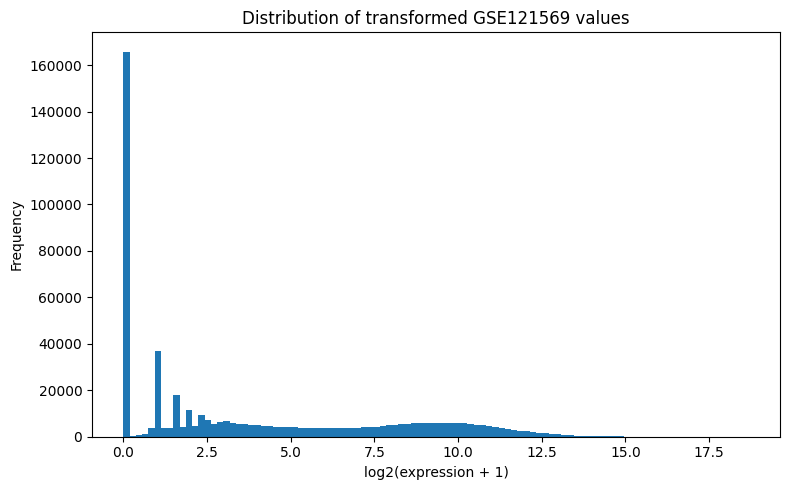

In [ ]:
# Plot the GSE121569 expression-value distribution after preprocessing.
# The large peak near zero shows that many gene-sample measurements have zero or very low expression.

plt.figure(
    figsize=(8, 5)
)

plt.hist(
    gse121569_expression
    .to_numpy()
    .ravel(),
    bins=100
)

plt.xlabel(
    "log2(expression + 1)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Distribution of transformed GSE121569 values"
)

plt.tight_layout()
plt.show()

The graph above has had a log2(expression + 1) transformation applied because the original expression values are non-negative. This reduces the large range of expression values without producing invalid values. The large peak around zero shows that many gene-expression measurements have zero or very low expression values. As the expression values increase, their frequency generally becomes lower, meaning that fewer measurements in the dataset show very high expression.

## 10 PCA of TDP-43 depletion versus control

PCA is applied to the TDP-43 dataset to see how the siTDP43 and siScr samples group or separate based on their overall gene-expression patterns.



,Sample,PC1,PC2,Condition
0,siScr_1,62.379994,14.213578,Control_siScr
1,siScr_2,49.869317,-8.750535,Control_siScr
2,siScr_3,-5.409935,32.806042,Control_siScr
3,siScr_4,-29.539668,-15.163799,Control_siScr
4,siScr_5,-51.337280,34.671579,Control_siScr
5,siScr_6,-52.456580,-14.192639,Control_siScr
6,siTDP43_1,99.204205,-7.372889,TDP43_KD
7,siTDP43_2,62.888496,-1.731446,TDP43_KD
8,siTDP43_3,-16.121096,-14.896512,TDP43_KD
9,siTDP43_4,-25.266305,0.714273,TDP43_KD


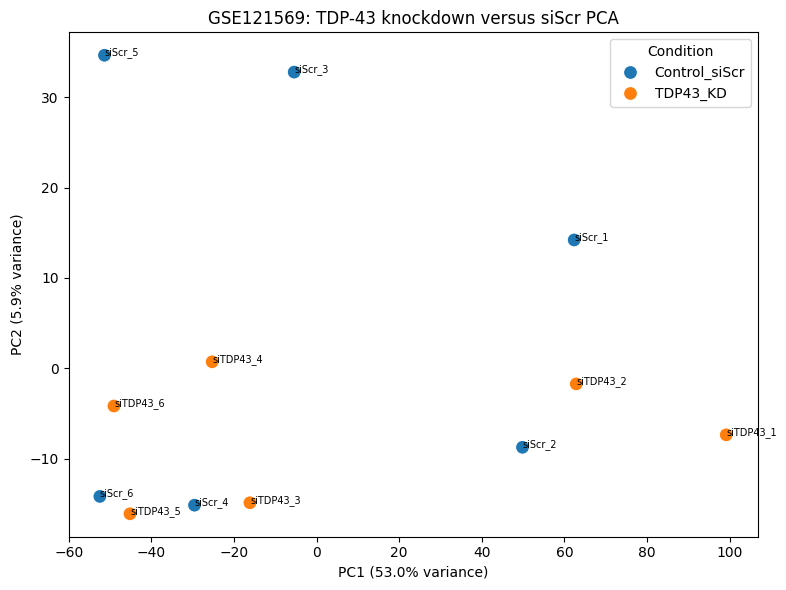

In [ ]:
# Run PCA on the TDP-43 dataset using the same PCA function as before.
# This shows how the siTDP43 and siScr samples group or separate in two dimensions.

(
    gse121569_pca_results,
    gse121569_pca_model,
    gse121569_pca_genes
) = run_pca(
    expression=gse121569_expression,
    metadata=gse121569_metadata,
    group_column="Condition",
    number_variable_genes=5000
)

display(
    gse121569_pca_results
)

plot_pca(
    pca_results=gse121569_pca_results,
    pca_model=gse121569_pca_model,
    group_column="Condition",
    title=(
        "GSE121569: TDP-43 knockdown "
        "versus siScr PCA"
    )
)

##PCA results for siScr and siTDP43

The PCA shows that PC1 explains 53.0% of the variation and PC2 explains a further 5.9%, giving a 2D view of 58.9% of the variation across the samples. However, the siTDP43 and siScr samples do not form clearly separate groups, with samples from both groups appearing in similar areas of the plot. There is also noticeable variation between samples within each group. Overall, the PCA does not show a clear separation between TDP-43 depletion and control based on the first two components.

In [ ]:
# Separate the GSE121569 samples into TDP-43 knockdown and scrambled-control lists.
# These lists are used for the gene-by-gene comparison.

tdp43_knockdown_samples = (
    gse121569_metadata.loc[
        gse121569_metadata["Condition"]
        == "TDP43_KD",
        "Sample"
    ].tolist()
)

tdp43_control_samples = (
    gse121569_metadata.loc[
        gse121569_metadata["Condition"]
        == "Control_siScr",
        "Sample"
    ].tolist()
)

print(
    "TDP-43 knockdown:",
    tdp43_knockdown_samples
)

print(
    "siScr controls:",
    tdp43_control_samples
)

TDP-43 knockdown: ['siTDP43_1', 'siTDP43_2', 'siTDP43_3', 'siTDP43_4', 'siTDP43_5', 'siTDP43_6']
siScr controls: ['siScr_1', 'siScr_2', 'siScr_3', 'siScr_4', 'siScr_5', 'siScr_6']


## 11 Gene-expression differences after TDP-43 depletion

For each gene, the average expression in siTDP43 is compared with the average expression in siScr using Welch's t-test. The difference is calculated as mean(siTDP43) − mean(siScr), showing the direction of the change. The resulting p-values are then corrected using Benjamini–Hochberg FDR to control false discoveries from testing thousands of genes.

In [ ]:
# Keep a copy of the TDP-43 differential-expression table before gene-ID mapping.
# The original Ensembl IDs are useful to retain for reference.

gse121569_de_ensembl = (
    run_welch_differential_expression(
        expression=gse121569_expression,
        case_samples=tdp43_knockdown_samples,
        control_samples=tdp43_control_samples,
        effect_column="TDP43_effect"
    )
)

display(
    gse121569_de_ensembl.head(20)
)

print(
    "FDR-significant genes:",
    (
        gse121569_de_ensembl["FDR"]
        < 0.05
    ).sum()
)

,Gene,mean_case,mean_control,TDP43_effect,t_statistic,pvalue,FDR,negative_log10_FDR
0,ENSG00000179715,5.564409,4.733671,0.830739,6.339904,0.000115,0.999998,8.252765e-07
1,ENSG00000183668,0.137709,1.338142,-1.200433,-5.692239,0.000217,0.999998,8.252765e-07
2,ENSG00000137673,8.987088,6.653511,2.333577,5.544864,0.000263,0.999998,8.252765e-07
3,ENSG00000227067,1.488259,0.182057,1.306202,6.296782,0.000268,0.999998,8.252765e-07
4,ENSG00000124491,4.301398,2.086630,2.214768,5.749538,0.000274,0.999998,8.252765e-07
5,ENSG00000114270,11.056548,9.999340,1.057208,5.164666,0.000514,0.999998,8.252765e-07
6,ENSG00000107738,5.309746,6.338051,-1.028305,-4.914559,0.000612,0.999998,8.252765e-07
7,ENSG00000222764,1.351018,0.171815,1.179203,4.861371,0.000660,0.999998,8.252765e-07
8,ENSG00000253304,5.446489,4.817641,0.628848,5.519576,0.000763,0.999998,8.252765e-07
9,ENSG00000179088,0.434253,1.690904,-1.256651,-4.740857,0.000839,0.999998,8.252765e-07


FDR-significant genes: 0


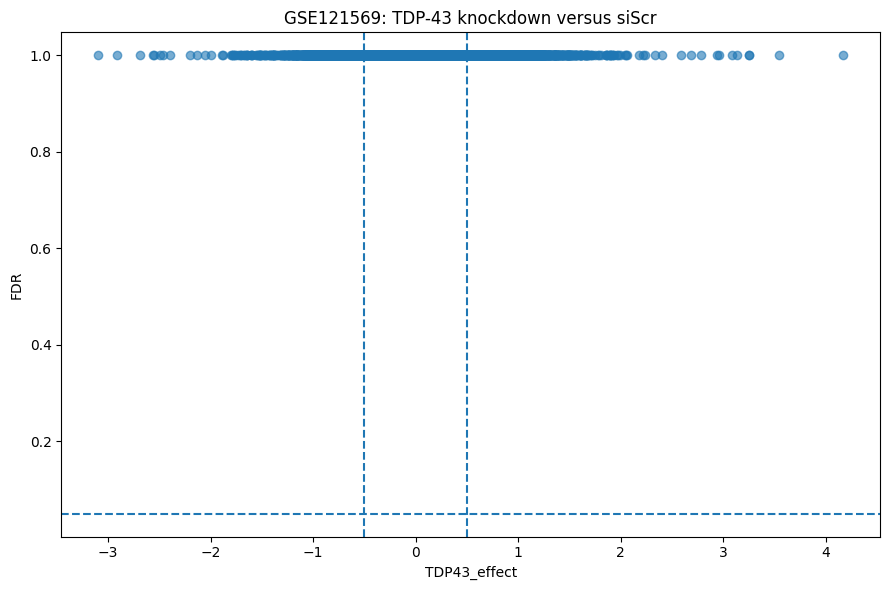

In [ ]:
# Use MyGene to map the GSE121569 Ensembl IDs to human gene symbols.
# This is the key step that lets the same biological genes be matched across the two datasets.

plot_volcano(
    results=gse121569_de_ensembl,
    effect_column="TDP43_effect",
    title=(
        "GSE121569: TDP-43 knockdown "
        "versus siScr"
    ),
    effect_threshold=0.5,
    fdr_threshold=0.05
)

The graph above shows the gene-expression differences between siTDP43 and siScr against their FDR values. The TDP-43 effect is calculated as mean(siTDP43) − mean(siScr). Genes towards the right have higher average expression in siTDP43 compared with siScr, while genes towards the left have lower average expression in siTDP43 compared with siScr. Genes closer to zero show smaller differences between the two groups. Although some genes show noticeable expression changes in either direction, none fall below the FDR threshold of 0.05. Therefore, no genes are considered statistically significant after the Benjamini–Hochberg correction.

## 12. Matching genes between the two datasets

Before the two datasets can be compared, the genes need to use the same type of identifier. GSE121569 uses Ensembl gene IDs, so mygene is used to match these IDs to their corresponding human gene symbols.

This gives both datasets a common way of identifying genes, almost like creating a shared dictionary between them. Genes that are successfully matched can then be joined across the ALS and TDP-43 datasets, allowing the expression change for the same gene to be compared between the two experiments.

Where the same gene symbol appears more than once after mapping, one result is kept so that each gene is represented once in the later comparison.



In [ ]:
# Attach the mapped gene symbols back to the TDP-43 results.
# Unmapped genes are kept aside because they cannot be matched reliably by symbol.

mygene_client = mygene.MyGeneInfo()

ensembl_ids = (
    gse121569_de_ensembl["Gene"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

mapping_records = mygene_client.querymany(
    ensembl_ids,
    scopes="ensembl.gene",
    fields="symbol,name,entrezgene",
    species="human",
    as_dataframe=False,
    verbose=False
)

gene_mapping = pd.DataFrame(
    mapping_records
)

gene_mapping = gene_mapping.rename(
    columns={
        "query": "Ensembl_ID"
    }
)

if "notfound" in gene_mapping.columns:

    gene_mapping = gene_mapping[
        gene_mapping["notfound"] != True
    ]

gene_mapping = gene_mapping.dropna(
    subset=["symbol"]
)

gene_mapping["symbol"] = (
    gene_mapping["symbol"]
    .astype(str)
    .str.upper()
    .str.strip()
)

gene_mapping = gene_mapping.drop_duplicates(
    subset="Ensembl_ID"
)

display(
    gene_mapping.head()
)

print(
    "Mapped genes:",
    gene_mapping["Ensembl_ID"].nunique()
)

,Ensembl_ID,_id,_score,entrezgene,name,symbol,notfound
0,ENSG00000179715,91523,32.413890,91523,PC-esterase domain containing 1B,PCED1B,NaN
1,ENSG00000183668,5678,32.414550,5678,pregnancy specific beta-1-glycoprotein 9,PSG9,NaN
2,ENSG00000137673,4316,31.433382,4316,matrix metallopeptidase 7,MMP7,NaN
3,ENSG00000227067,ENSG00000227067,10.456176,NaN,DPPA3 pseudogene 1,DPPA3P1,NaN
4,ENSG00000124491,2162,31.432636,2162,coagulation factor XIII A chain,F13A1,NaN


Mapped genes: 32537


In [ ]:
# Keep one result for each mapped gene symbol.
# If a symbol appears more than once, the row with stronger statistical evidence is kept first.

gse121569_de = (
    gse121569_de_ensembl.merge(
        gene_mapping[
            ["Ensembl_ID", "symbol"]
        ],
        left_on="Gene",
        right_on="Ensembl_ID",
        how="left"
    )
)

gse121569_de = (
    gse121569_de
    .dropna(
        subset=["symbol"]
    )
    .copy()
)

gse121569_de["symbol"] = (
    gse121569_de["symbol"]
    .str.upper()
    .str.strip()
)

gse121569_de = (
    gse121569_de
    .sort_values(
        ["FDR", "pvalue"],
        na_position="last"
    )
    .drop_duplicates(
        subset="symbol"
    )
    .reset_index(drop=True)
)

display(
    gse121569_de.head(20)
)

,Gene,mean_case,mean_control,TDP43_effect,t_statistic,pvalue,FDR,negative_log10_FDR,Ensembl_ID,symbol
0,ENSG00000179715,5.564409,4.733671,0.830739,6.339904,0.000115,0.999998,8.252765e-07,ENSG00000179715,PCED1B
1,ENSG00000183668,0.137709,1.338142,-1.200433,-5.692239,0.000217,0.999998,8.252765e-07,ENSG00000183668,PSG9
2,ENSG00000137673,8.987088,6.653511,2.333577,5.544864,0.000263,0.999998,8.252765e-07,ENSG00000137673,MMP7
3,ENSG00000227067,1.488259,0.182057,1.306202,6.296782,0.000268,0.999998,8.252765e-07,ENSG00000227067,DPPA3P1
4,ENSG00000124491,4.301398,2.086630,2.214768,5.749538,0.000274,0.999998,8.252765e-07,ENSG00000124491,F13A1
5,ENSG00000114270,11.056548,9.999340,1.057208,5.164666,0.000514,0.999998,8.252765e-07,ENSG00000114270,COL7A1
6,ENSG00000107738,5.309746,6.338051,-1.028305,-4.914559,0.000612,0.999998,8.252765e-07,ENSG00000107738,VSIR
7,ENSG00000222764,1.351018,0.171815,1.179203,4.861371,0.000660,0.999998,8.252765e-07,ENSG00000222764,RN7SKP106
8,ENSG00000253304,5.446489,4.817641,0.628848,5.519576,0.000763,0.999998,8.252765e-07,ENSG00000253304,TMEM200B
9,ENSG00000179088,0.434253,1.690904,-1.256651,-4.740857,0.000839,0.999998,8.252765e-07,ENSG00000179088,C12ORF42


In [ ]:
# Standardise the ALS gene symbols by using uppercase text and removing extra spaces.
# This helps avoid missed matches caused only by different text formatting.

gse76220_comparison = (
    gse76220_de.copy()
)

gse76220_comparison["symbol"] = (
    gse76220_comparison["Gene"]
    .astype(str)
    .str.upper()
    .str.strip()
)

gse76220_comparison = (
    gse76220_comparison
    .sort_values(
        ["FDR", "pvalue"],
        na_position="last"
    )
    .drop_duplicates(
        subset="symbol"
    )
)

## 13. Comparing the ALS and TDP-43 results

After the same genes have been matched between the two datasets using Ensembl IDs in the previous steps, their expression changes can be compared. The main question is whether genes that change in ALS also show similar changes after TDP-43 depletion.

Several comparisons are used to look at this relationship:

Spearman correlation – checks whether genes with larger or smaller expression changes in ALS also tend to show larger or smaller changes after TDP-43 depletion.
SciPy documentation: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html

Same-direction comparison – checks how many shared genes increase or decrease in the same direction in both datasets.
NumPy documentation: https://numpy.org/doc/stable/reference/generated/numpy.sign.html

Hypergeometric test – checks whether the number of significant genes shared between the two datasets is greater than would be expected by chance. In this analysis, no genes passed the FDR threshold, so there was no significant overlap to support this comparison.
SciPy documentation: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.hypergeom.html


In [ ]:
# Join the ALS and TDP-43 results using the common gene symbol.
# Each row now represents the same biological gene with an effect from both datasets.

# Inner merge means only genes found in both datasets are kept for the direct comparison.
cross_dataset_results = (
    gse76220_comparison[
        [
            "symbol",
            "ALS_effect",
            "pvalue",
            "FDR"
        ]
    ]
    .rename(
        columns={
            "pvalue": "ALS_pvalue",
            "FDR": "ALS_FDR"
        }
    )
    .merge(
        gse121569_de[
            [
                "symbol",
                "TDP43_effect",
                "pvalue",
                "FDR",
                "Gene"
            ]
        ]
        .rename(
            columns={
                "pvalue": "TDP43_pvalue",
                "FDR": "TDP43_FDR",
                "Gene": "TDP43_Ensembl_ID"
            }
        ),
        on="symbol",
        how="inner"
    )
)

# Compare the signs of the two effects: positive/positive and negative/negative count as the same direction.
cross_dataset_results[
    "same_direction"
] = (
    np.sign(
        cross_dataset_results[
            "ALS_effect"
        ]
    )
    ==
    np.sign(
        cross_dataset_results[
            "TDP43_effect"
        ]
    )
)

print(
    "Shared genes:",
    len(cross_dataset_results)
)

display(
    cross_dataset_results.head()
)

Shared genes: 14195


,symbol,ALS_effect,ALS_pvalue,ALS_FDR,TDP43_effect,TDP43_pvalue,TDP43_FDR,TDP43_Ensembl_ID,same_direction
0,KCNA1,-0.486808,0.000030,0.239433,-0.432680,0.694270,0.999998,ENSG00000111262,True
1,KLHL18,1.529557,0.000036,0.239433,0.701891,0.270745,0.999998,ENSG00000114648,True
2,CUX2,-1.431305,0.000038,0.239433,0.126990,0.805307,0.999998,ENSG00000111249,False
3,EPB41,-0.402397,0.000084,0.243585,0.370502,0.433936,0.999998,ENSG00000159023,False
4,PRUNE2,-1.000045,0.000088,0.243585,-0.198847,0.754368,0.999998,ENSG00000106772,True


In [ ]:
# Measure the overall relationship between ALS and TDP-43 gene effects using Spearman correlation.
# Also calculate how often the two effects have the same positive or negative direction.

# Spearman compares the rank ordering of effects rather than requiring the exact effect sizes to match.
effect_correlation, correlation_pvalue = (
    spearmanr(
        cross_dataset_results[
            "ALS_effect"
        ],
        cross_dataset_results[
            "TDP43_effect"
        ],
        nan_policy="omit"
    )
)

same_direction_fraction = (
    cross_dataset_results[
        "same_direction"
    ].mean()
)

print(
    "Spearman correlation:",
    effect_correlation
)

print(
    "Correlation p-value:",
    correlation_pvalue
)

print(
    "Same-direction fraction:",
    same_direction_fraction
)

Spearman correlation: 0.022395352537193845
Correlation p-value: 0.007622616196908403
Same-direction fraction: 0.5628038041563931


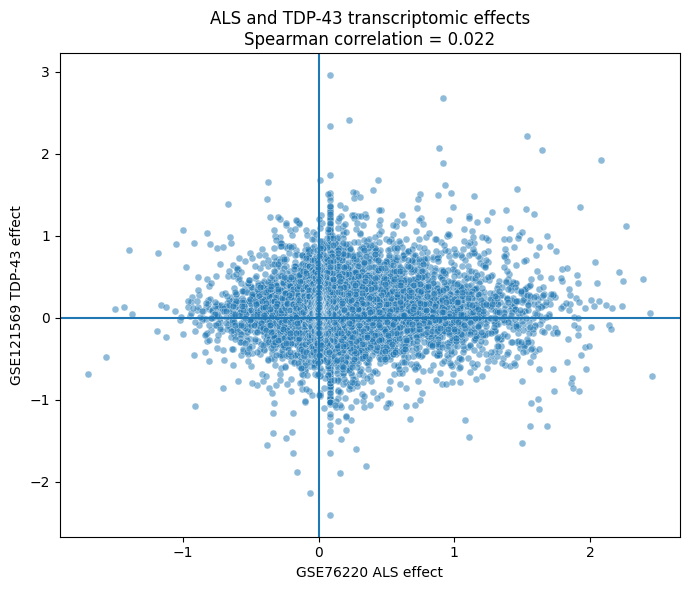

In [ ]:
# Plot the ALS effect against the TDP-43 effect for every matched gene.
# A clear diagonal pattern would suggest stronger agreement; a scattered cloud suggests little overall relationship.

plt.figure(
    figsize=(7, 6)
)

sns.scatterplot(
    data=cross_dataset_results,
    x="ALS_effect",
    y="TDP43_effect",
    s=25,
    alpha=0.5
)

plt.axhline(
    0
)

plt.axvline(
    0
)

plt.xlabel(
    "GSE76220 ALS effect"
)

plt.ylabel(
    "GSE121569 TDP-43 effect"
)

plt.title(
    "ALS and TDP-43 transcriptomic effects\n"
    f"Spearman correlation = "
    f"{effect_correlation:.3f}"
)

plt.tight_layout()
plt.show()

The graph above compares the ALS effect with the TDP-43 depletion effect for each gene matched between the two datasets. Spearman correlation compares the ranking of these gene-expression effects. If the two datasets showed a strong similar pattern, genes with larger positive or negative effects in ALS would also tend to show corresponding effects after TDP-43 depletion. However, the points are widely scattered without a clear pattern. The Spearman correlation of 0.022 is very close to zero, showing little evidence that genes with larger changes in ALS also tend to have larger changes after TDP-43 depletion. This suggests that there is little overall relationship between the ranked gene-expression effects across the two datasets.

In [ ]:
# Mark genes that pass FDR < 0.05 in each dataset.
# Then check whether any of those significant genes are shared between both datasets.

cross_dataset_results[
    "ALS_significant"
] = (
    cross_dataset_results[
        "ALS_FDR"
    ] < 0.05
)

cross_dataset_results[
    "TDP43_significant"
] = (
    cross_dataset_results[
        "TDP43_FDR"
    ] < 0.05
)

cross_dataset_results[
    "significant_in_both"
] = (
    cross_dataset_results[
        "ALS_significant"
    ]
    &
    cross_dataset_results[
        "TDP43_significant"
    ]
)

# Keep only genes that pass FDR < 0.05 in both datasets.
significant_overlap = (
    cross_dataset_results[
        cross_dataset_results[
            "significant_in_both"
        ]
    ].copy()
)

print(
    "Significant overlapping genes:",
    len(significant_overlap)
)

display(
    significant_overlap.head(30)
)

Significant overlapping genes: 0


,symbol,ALS_effect,ALS_pvalue,ALS_FDR,TDP43_effect,TDP43_pvalue,TDP43_FDR,TDP43_Ensembl_ID,same_direction,ALS_significant,TDP43_significant,significant_in_both


In [ ]:
# Use a hypergeometric test to ask whether the significant-gene overlap is greater than expected by chance.
# The shared matched genes form the background gene universe for this test.

shared_universe = len(
    cross_dataset_results
)

als_significant_count = int(
    cross_dataset_results[
        "ALS_significant"
    ].sum()
)

tdp43_significant_count = int(
    cross_dataset_results[
        "TDP43_significant"
    ].sum()
)

overlap_count = int(
    cross_dataset_results[
        "significant_in_both"
    ].sum()
)

# The survival function gives the probability of seeing this overlap or a larger one by chance.
overlap_pvalue = hypergeom.sf(
    overlap_count - 1,
    shared_universe,
    als_significant_count,
    tdp43_significant_count
)

print(
    "Shared gene universe:",
    shared_universe
)

print(
    "ALS significant:",
    als_significant_count
)

print(
    "TDP-43 significant:",
    tdp43_significant_count
)

print(
    "Overlap:",
    overlap_count
)

print(
    "Hypergeometric p-value:",
    overlap_pvalue
)

Shared gene universe: 14195
ALS significant: 0
TDP-43 significant: 0
Overlap: 0
Hypergeometric p-value: 1.0


## 14. Genes of biological interest

Alongside the comparison of all matched genes, a small group of genes with clear relevance to ALS and TDP-43 biology is examined more closely.

The genes included are:

- C9orf72
- SOD1
- TARDBP
- FUS
- STMN2

C9orf72, SOD1, TARDBP, and FUS are major ALS-associated genes highlighted by the ALS Association. STMN2 is included because it is directly relevant to the GSE121569 study, where reduced TDP-43 function was shown to affect STMN2 expression.

This section looks at how these specific genes behave across the two datasets.

https://www.als.org/research/als-research-topics/genetics



In [ ]:
# Select the five genes chosen for a closer biological comparison.
# Their ALS and TDP-43 effects, p-values, FDR values and change direction are shown side by side.

genes_of_interest = [
    "C9ORF72",
    "SOD1",
    "TARDBP",
    "FUS",
    "STMN2"
]

# Pull these five genes from the ALS results.
als_key_results = (
    gse76220_comparison[
        gse76220_comparison[
            "symbol"
        ].isin(
            genes_of_interest
        )
    ]
    [
        [
            "symbol",
            "ALS_effect",
            "pvalue",
            "FDR"
        ]
    ]
    .rename(
        columns={
            "pvalue": "ALS_pvalue",
            "FDR": "ALS_FDR"
        }
    )
)

# Pull the same five genes from the TDP-43 results.
tdp43_key_results = (
    gse121569_de[
        gse121569_de[
            "symbol"
        ].isin(
            genes_of_interest
        )
    ]
    [
        [
            "symbol",
            "TDP43_effect",
            "pvalue",
            "FDR"
        ]
    ]
    .rename(
        columns={
            "pvalue": "TDP43_pvalue",
            "FDR": "TDP43_FDR"
        }
    )
)

# Join the two sets side by side so the same gene can be read across one row.
key_gene_results = (
    pd.DataFrame({
        "symbol": genes_of_interest
    })
    .merge(
        als_key_results,
        on="symbol",
        how="left"
    )
    .merge(
        tdp43_key_results,
        on="symbol",
        how="left"
    )
)

# Check whether each selected gene increases or decreases in the same direction in both datasets.
key_gene_results[
    "same_direction"
] = (
    np.sign(
        key_gene_results[
            "ALS_effect"
        ]
    )
    ==
    np.sign(
        key_gene_results[
            "TDP43_effect"
        ]
    )
)

display(
    key_gene_results
)

,symbol,ALS_effect,ALS_pvalue,ALS_FDR,TDP43_effect,TDP43_pvalue,TDP43_FDR,same_direction
0,C9ORF72,0.022128,0.898851,0.955414,0.063320,0.890196,0.999998,True
1,SOD1,-0.026596,0.857356,0.935156,0.111848,0.812731,0.999998,False
2,TARDBP,0.240961,0.029032,0.569639,-1.238890,0.034421,0.999998,False
3,FUS,0.201030,0.100195,0.793427,0.094876,0.859634,0.999998,True
4,STMN2,-0.908263,0.008943,0.470919,-1.079346,0.028537,0.999998,True


The table above compares the five selected genes across the ALS and TDP-43 datasets. C9ORF72, FUS and STMN2 change in the same direction in both datasets, while SOD1 and TARDBP change in opposite directions. STMN2 shows one of the larger expression changes among these selected genes, with lower expression in both ALS (−0.908) and after TDP-43 depletion (−1.079). TARDBP shows higher expression in ALS (0.241) but lower expression after TDP-43 depletion (−1.239), which is consistent with the TDP-43 knockdown design. Although STMN2 and TARDBP have relatively small raw p-values, none of the five genes pass the FDR threshold of 0.05 and therefore cannot be considered statistically significant. If enough genes had remained significant after FDR correction, Enrichr could have been used to look for common biological processes or pathways between the ALS and TDP-43 results, providing another way of investigating the main question of whether the two datasets show a measurable relationship. Since this was not possible here, future work could use larger datasets or investigate transcript-level, exon-level and RNA-splicing changes to further explore the relationship between TDP-43 dysfunction and ALS.

## 13. Conclusions and limitations

This project investigated whether gene-expression changes in sporadic ALS spinal motor neurons show measurable similarities with changes following TDP-43 depletion. Some similarities were observed, including genes that changed in the same direction across both datasets. However, the overall Spearman correlation was very low at 0.022, and no genes remained statistically significant after the Benjamini–Hochberg correction at FDR < 0.05. This means that there was not enough statistical evidence from these datasets to show an overall similarity between the ALS and TDP-43 depletion gene-expression changes.

Some genes of biological interest still showed noticeable patterns. STMN2 showed lower expression in both ALS and after TDP-43 depletion, while TARDBP showed lower expression following TDP-43 depletion as expected from the experimental design. However, these results did not survive FDR correction and therefore cannot be considered statistically significant findings.

Several limitations may have affected the results. The datasets contain relatively small numbers of samples, which can make reliable gene-expression differences more difficult to detect. Biological heterogeneity, meaning natural differences between individual biological samples, may also contribute to the variation seen within the groups. The two studies also use different experimental systems and data-processing methods, and some genes may be lost when matching gene identifiers between the datasets.

TDP-43 dysfunction may also affect ALS through changes that cannot be fully identified by comparing overall gene-expression levels. Future work could use larger and more closely matched datasets or investigate transcript-level, exon-level and RNA-splicing changes to further explore the relationship between TDP-43 dysfunction and ALS.